In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DataFrame as df

Question: Predicting Student Mental Health Score from Social Media Usage
Problem: We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

Dataset: Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

In [2]:
df=pd.read_csv("../data/Student Social Media And Mental Health Impact.csv")

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.isnull()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

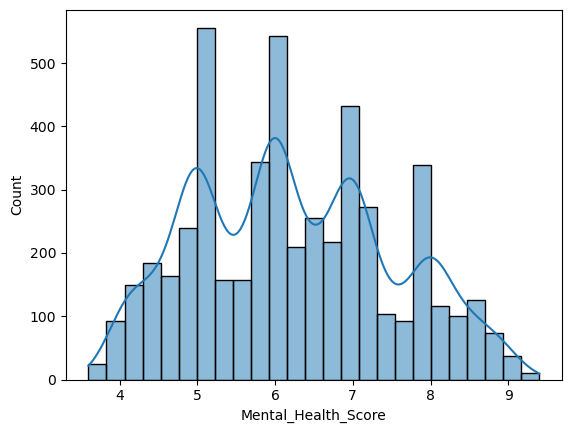

In [9]:
#Exploratory Data Analysis
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

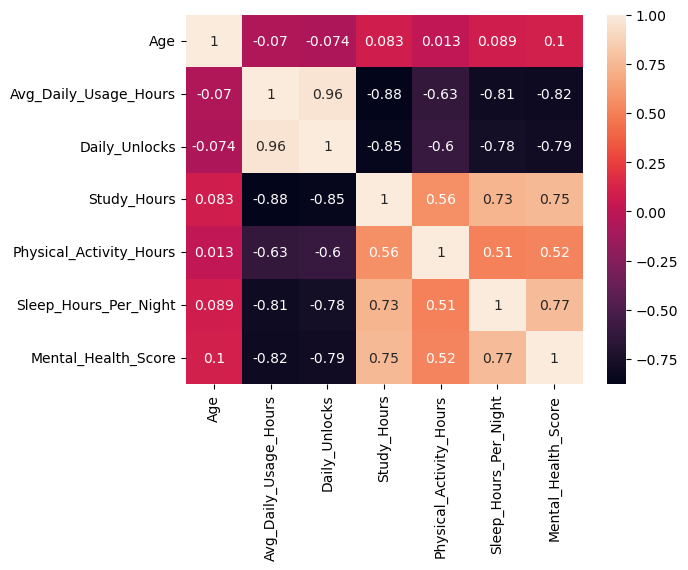

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:


df['Stress_Level'].unique() # STRESS lEVEL VS MENTAL HEALTH 

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

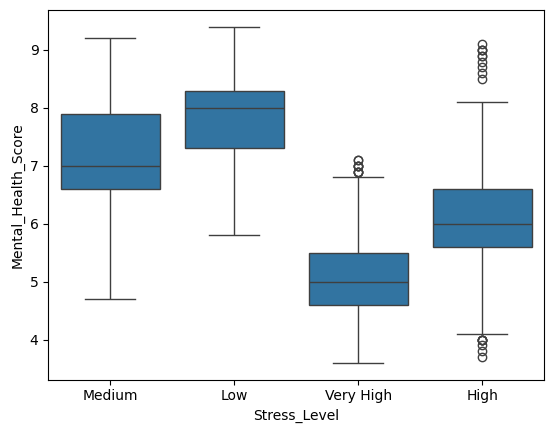

In [12]:
order=['Medium', 'Low', 'Very High', 'High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

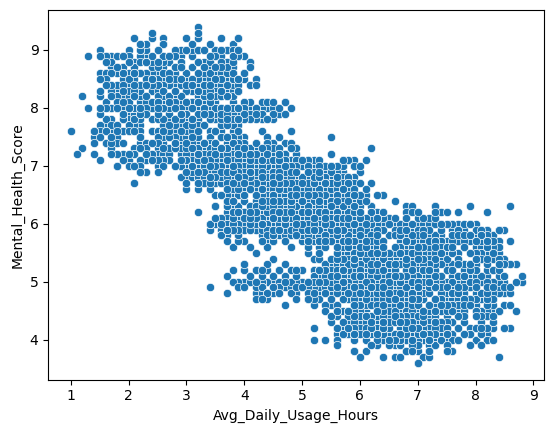

In [13]:
#Does More Time On social media relate to low scoring? yes according to scatter plot

sns.scatterplot(x='Avg_Daily_Usage_Hours',y= 'Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

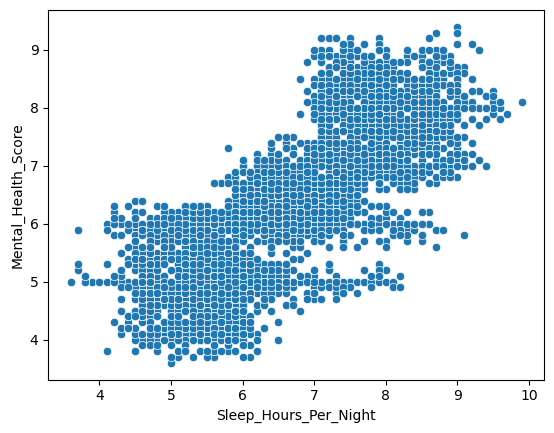

In [14]:
#How does sleep affect mental health

sns.scatterplot(x='Sleep_Hours_Per_Night',y= 'Mental_Health_Score',data=df)

In [15]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

Text(0, 0.5, 'Counts')

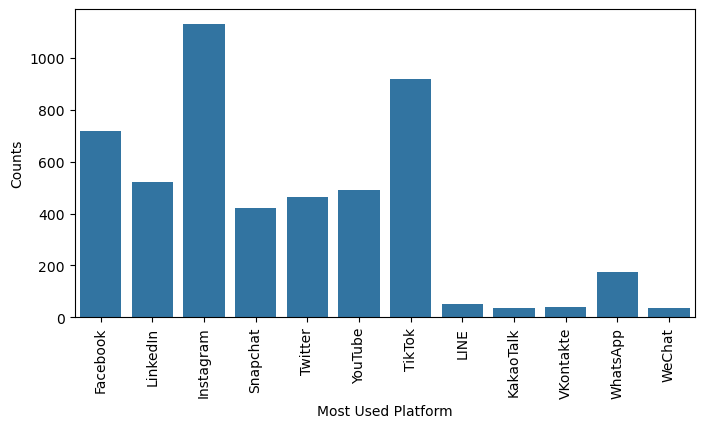

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(x='Most_Used_Platform',data=df)
plt.xticks(rotation=90)
plt.xlabel("Most Used Platform")
plt.ylabel("Counts")

In [17]:
#Checking Outliers

num_features=df.select_dtypes(include='number') #int64 or float64
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [18]:
Q1 = num_features.quantile(0.25) #to get outliers we need to get quartile 1 quartile 3 and IQR then get lower bound and upper bound
Q3 = num_features.quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=(num_features<lower_bound)|(num_features>upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [19]:
# 1 task one is to drop duplicates adn extract the necessary data 
df=df.drop_duplicates()

#2Converting negative value to required realistic
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [20]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [21]:
# skewness is to show whether the data is at the centre or at the left or AT THE RIGHT AND AT WHAT VALUE
#Models like linear regression assume that features are well behaved but in reality its not so skewness will help us where to lokk for more predictions 
num_cols=df.select_dtypes(include='number')
num_cols.skew()
#near to zero value =centralized
#negative= left skewed
#positive=right skewed

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [22]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [23]:
def group_countries(country):
    if country in top_countries:
     return country
    else:
        return 'Other'

In [24]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [25]:
df[['Country','Grouped_country']].head(10)

,Country,Grouped_country
0,Other,Other
1,Other,Other
2,Canada,Canada
3,Other,Other
4,Other,Other
5,Other,Other
6,Other,Other
7,Other,Other
8,USA,USA
9,Other,Other


In [26]:
df['Grouped_country'].value_counts() # to make encoding easy 

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [27]:
#onehotencoding -Categories that does not have any order 
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]


feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
     

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
#1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])


    # (konsi_pipeline, konsa_feature)
preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skwewd_col),
    ("Plain_Numeric",plain_numeric_pipeline, other_numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])




1. Build a Pipeline
Why Pipeline matters: a Pipeline chains preprocessing and the model into a single object. Calling .fit() once does both steps in the correct order, and calling .predict() on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

Why companies prefer this: when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know anything about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls .predict() on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.739794461743302
MAE 0.5361775634720183


In [30]:
from sklearn.ensemble import RandomForestRegressor #To save data leakage #MAE should be less

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")


Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
MAE : 0.34722113333333343


In [31]:

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [33]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [34]:
random_search.best_score_

np.float64(0.8407094379948846)

In [35]:
best_rf_model = random_search.best_estimator_

best_rf_model

,steps,"[('preprocessor', ...), ('random forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Skewed_Pipeline', ...), ('Plain_Numeric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
best_rf_preds = best_rf_model.predict(X_test)
best_rf_train_preds = best_rf_model.predict(X_train)

best_rf_r2_test = r2_score(y_test, best_rf_preds)
best_rf_r2_train = r2_score(y_train, best_rf_train_preds)

best_rf_mae = mean_absolute_error(y_test, best_rf_preds)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_preds))

print(f"Training R² : {best_rf_r2_train:.4f}")
print(f"Testing R²  : {best_rf_r2_test:.4f}")
print(f"MAE         : {best_rf_mae:.4f}")
print(f"RMSE        : {best_rf_rmse:.4f}")

Training R² : 0.9547
Testing R²  : 0.8650
MAE         : 0.3689
RMSE        : 0.4869


In [37]:
#Compare Linear Regression vs Random Forest
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Tuned Random Forest'],
    'R2 Score': [
        lr_r2_testing,
        rf_r2_testing,
        best_rf_r2_test
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        best_rf_mae
    ]
})

model_comparison

,Model,R2 Score,MAE
0,Linear Regression,0.739794,0.536178
1,Random Forest,0.877589,0.347221
2,Tuned Random Forest,0.865014,0.368902


In [38]:
model_comparison.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE
1,Random Forest,0.877589,0.347221
2,Tuned Random Forest,0.865014,0.368902
0,Linear Regression,0.739794,0.536178


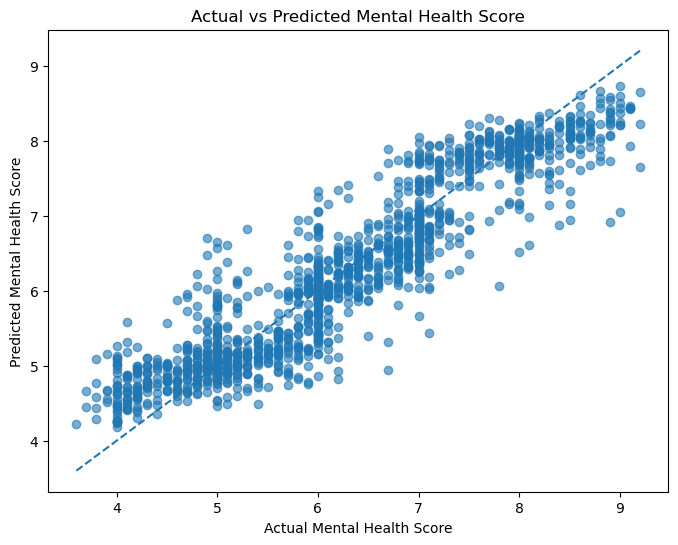

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, best_rf_preds, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")
plt.title("Actual vs Predicted Mental Health Score")

plt.show() #If predictions are good, the points should be concentrated around the diagonal line.

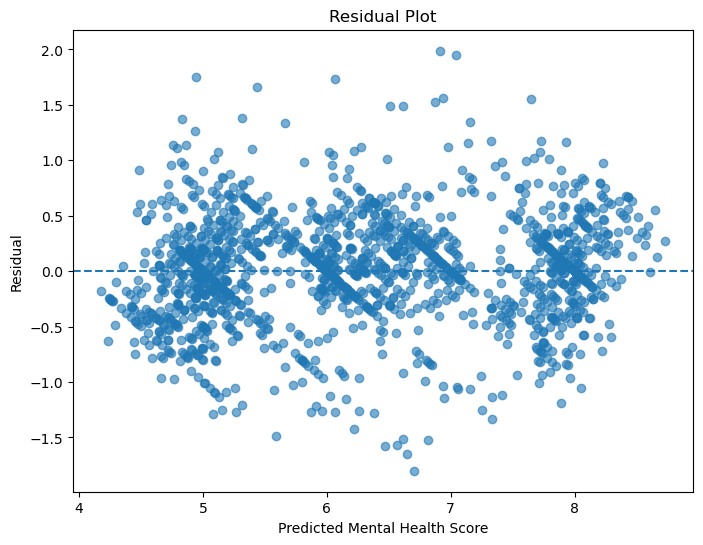

In [40]:
#Residual Analysis

#Now we check where the model makes errors.

residuals = y_test - best_rf_preds

plt.figure(figsize=(8,6))

plt.scatter(best_rf_preds, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Mental Health Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

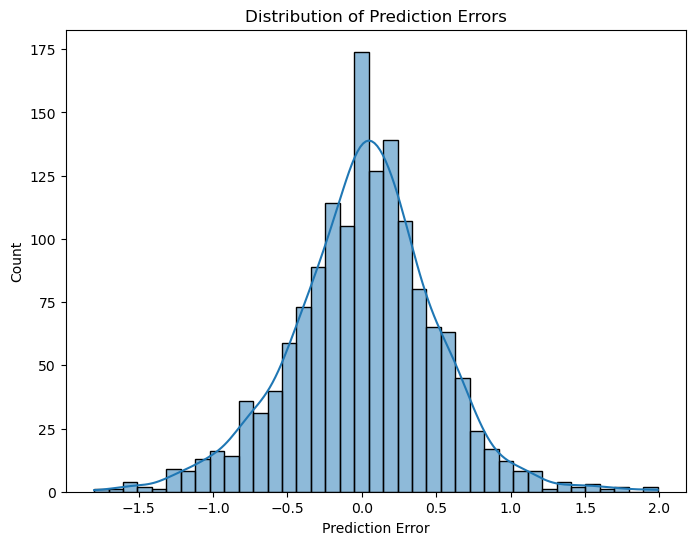

In [41]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.show()

In [45]:
preprocessor_fitted = best_rf_model.named_steps['preprocessor']

print("Preprocessor structure:\n")
print(preprocessor_fitted)

print("\n\nTransformers:\n")

for name, transformer, columns in preprocessor_fitted.transformers_:
    print("Name:", name)
    print("Transformer type:", type(transformer))
    print("Columns:", columns)
    print("-" * 60)

Preprocessor structure:

ColumnTransformer(transformers=[('Skewed_Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain_Numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                   

In [46]:
from sklearn.preprocessing import OneHotEncoder

rf_model = best_rf_model.named_steps['random forest']
preprocessor_fitted = best_rf_model.named_steps['preprocessor']

feature_names = []

for name, transformer, columns in preprocessor_fitted.transformers_:

    if name == 'remainder':
        continue

    # Handle categorical pipeline containing OneHotEncoder
    if hasattr(transformer, 'named_steps') and 'encode' in transformer.named_steps:

        encoder = transformer.named_steps['encode']

        if isinstance(encoder, OneHotEncoder):
            names = encoder.get_feature_names_out(columns)
            feature_names.extend(names)
        else:
            feature_names.extend(columns)

    # Numerical / ordinal pipelines
    else:
        feature_names.extend(columns)


# Check that everything matches
print("Number of transformed features:", len(feature_names))
print("Number of Random Forest importances:", len(rf_model.feature_importances_))

# Create feature importance table
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

Number of transformed features: 38
Number of Random Forest importances: 38


,Feature,Importance
2,Avg_Daily_Usage_Hours,0.716564
5,Sleep_Hours_Per_Night,0.101528
3,Daily_Unlocks,0.040670
0,Study_Hours,0.023125
4,Physical_Activity_Hours,0.022185
1,Age,0.014133
25,Purpose_Of_Use_Entertainment,0.008773
35,Grouped_country_Turkey,0.006430
34,Grouped_country_Other,0.005610
13,Most_Used_Platform_Instagram,0.005352


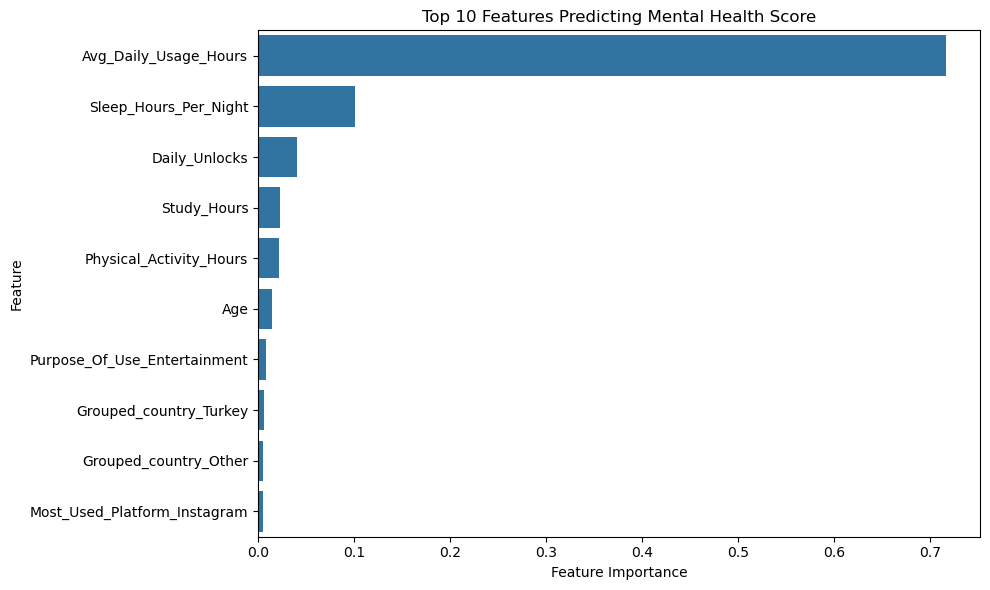

In [47]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features Predicting Mental Health Score")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [48]:
# Final evaluation of the tuned Random Forest

best_rf_preds = best_rf_model.predict(X_test)
best_rf_train_preds = best_rf_model.predict(X_train)

# Calculate metrics
final_train_r2 = r2_score(y_train, best_rf_train_preds)
final_test_r2 = r2_score(y_test, best_rf_preds)
final_mae = mean_absolute_error(y_test, best_rf_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, best_rf_preds))

print("FINAL MODEL PERFORMANCE")
print("-" * 35)
print(f"Training R² : {final_train_r2:.4f}")
print(f"Testing R²  : {final_test_r2:.4f}")
print(f"MAE         : {final_mae:.4f}")
print(f"RMSE        : {final_rmse:.4f}")

FINAL MODEL PERFORMANCE
-----------------------------------
Training R² : 0.9547
Testing R²  : 0.8650
MAE         : 0.3689
RMSE        : 0.4869


In [50]:
#So tuning did not improve the model:

#R²: 0.8776 → 0.8650 ❌
#MAE: 0.3472 → 0.3689 ❌

# Use the original Random Forest because it performed better
final_model = rf_pipeline

# Predictions
final_train_preds = final_model.predict(X_train)
final_test_preds = final_model.predict(X_test)

# Metrics
final_train_r2 = r2_score(y_train, final_train_preds)
final_test_r2 = r2_score(y_test, final_test_preds)
final_mae = mean_absolute_error(y_test, final_test_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_test_preds))

print("FINAL SELECTED MODEL")
print("-" * 35)
print(f"Model       : Random Forest")
print(f"Training R² : {final_train_r2:.4f}")
print(f"Testing R²  : {final_test_r2:.4f}")
print(f"MAE         : {final_mae:.4f}")
print(f"RMSE        : {final_rmse:.4f}")

FINAL SELECTED MODEL
-----------------------------------
Model       : Random Forest
Training R² : 0.9808
Testing R²  : 0.8776
MAE         : 0.3472
RMSE        : 0.4637


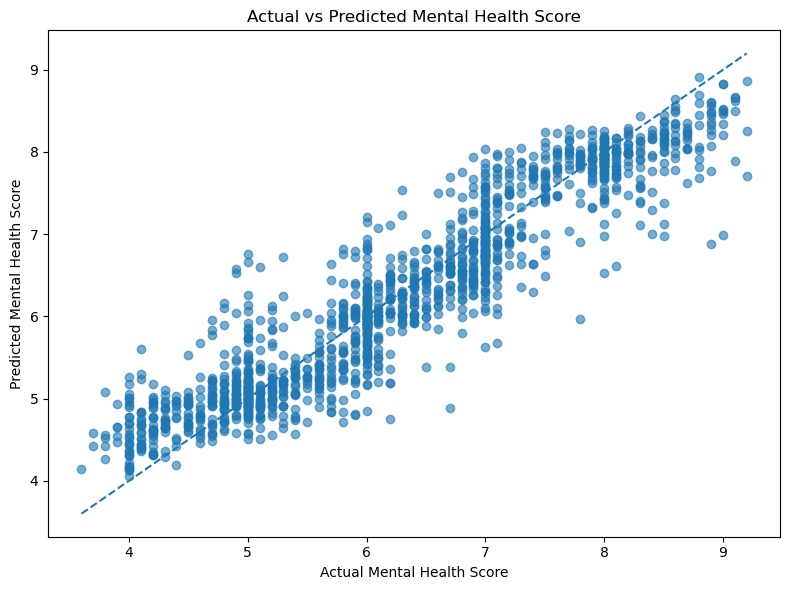

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_test_preds,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")
plt.title("Actual vs Predicted Mental Health Score")

plt.tight_layout()
plt.show()

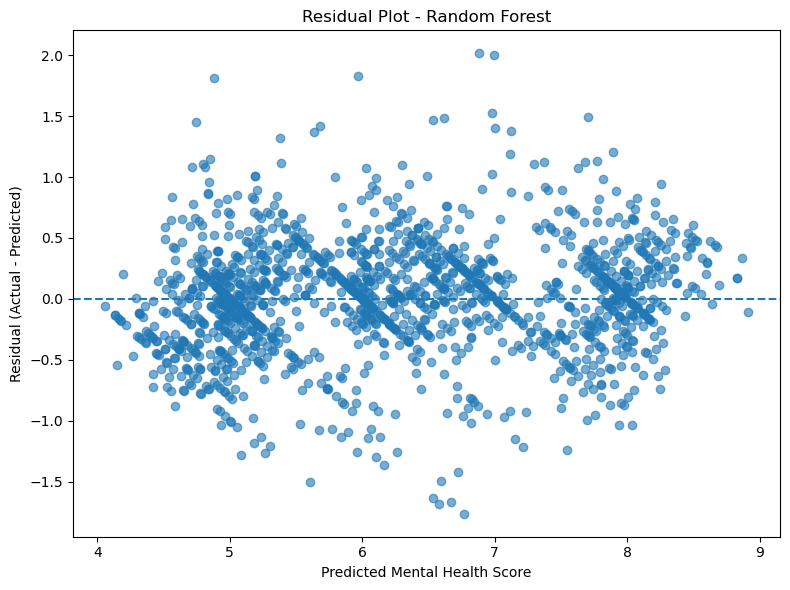

In [52]:
# Calculate residuals
residuals = y_test - final_test_preds

plt.figure(figsize=(8, 6))

plt.scatter(
    final_test_preds,
    residuals,
    alpha=0.6
)

# Zero-error reference line
plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Mental Health Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Random Forest")

plt.tight_layout()
plt.show()

In [53]:
import joblib

# Save the selected final model
joblib.dump(final_model, "mental_health_prediction_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [54]:
loaded_model = joblib.load("mental_health_prediction_model.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [55]:
#Test the Final Model With a New Student
new_student = pd.DataFrame({
    'Study_Hours': [6],
    'Age': [21],
    'Avg_Daily_Usage_Hours': [3],
    'Daily_Unlocks': [100],
    'Physical_Activity_Hours': [2],
    'Sleep_Hours_Per_Night': [7],
    'Stress_Level': ['Medium'],
    'Gender': ['Male'],
    'Academic_Level': ['Undergraduate'],
    'Most_Used_Platform': ['Instagram'],
    'Purpose_Of_Use': ['Entertainment'],
    'Grouped_country': ['Other']
})

prediction = final_model.predict(new_student)

print(f"Predicted Mental Health Score: {prediction[0]:.2f}")

Predicted Mental Health Score: 7.43


In [56]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("mental_health_prediction_model.pkl")

# Test student
test_student = pd.DataFrame({
    'Study_Hours': [6],
    'Age': [21],
    'Avg_Daily_Usage_Hours': [3],
    'Daily_Unlocks': [100],
    'Physical_Activity_Hours': [2],
    'Sleep_Hours_Per_Night': [7],
    'Stress_Level': ['Medium'],
    'Gender': ['Male'],
    'Academic_Level': ['Undergraduate'],
    'Most_Used_Platform': ['Instagram'],
    'Purpose_Of_Use': ['Entertainment'],
    'Grouped_country': ['Other']
})

prediction = model.predict(test_student)[0]

print(f"Predicted Mental Health Score: {prediction:.2f}")

Predicted Mental Health Score: 7.43


In [57]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [58]:
import joblib

joblib.dump(model, "mental_health_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 0.34722113333333343
RMSE: 0.46368105222591677
R²  : 0.8775888638668996


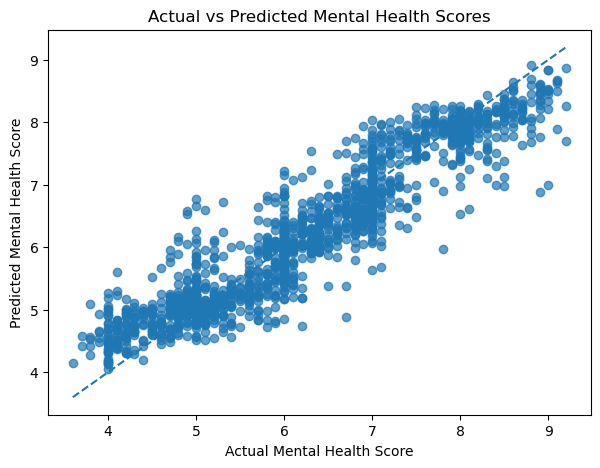

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")
plt.title("Actual vs Predicted Mental Health Scores")

plt.show()

In [63]:
import joblib

joblib.dump(model, "mental_health_model.pkl")

print("Model saved successfully!")

Model saved successfully!
